# Multi-Asset Portfolio Optimization and Robustness Analysis

This notebook applies mean-variance optimization to nine ETFs spanning equities, bonds, gold, real estate, and commodities over 2010–2025. It tests the optimized portfolios in sample, in a rolling out-of-sample backtest, and under bootstrap resampling, and asks whether simple 5–35% allocation bounds make the results more robust.

**Summary of results**

- **In sample:** Unconstrained maximum Sharpe optimization concentrates in QQQ, GLD, and TLT (Sharpe ratio 1.14). The 5–35% bounds lower the estimated Sharpe ratio to 1.01 in exchange for a diversified allocation.
- **Out of sample, before costs:** The backtest re-estimates on a rolling two-year window and rebalances every 21 trading days, with holdings drifting in between.
  - The constrained strategy had a Sharpe ratio of 0.91, compared with 0.82 for the unconstrained strategy, 0.77 for equal weight, and 0.85 for SPY.
  - Its maximum drawdown was −19.2%, versus −26.4%, −22.8%, and −33.7% respectively.
  - It traded about 37% less than the unconstrained strategy (111% vs 176% annual turnover).
  - SPY had by far the highest CAGR (14.0% vs 8.9% for either optimized strategy).
- **After transaction costs:** At 25 bps per dollar traded, the constrained strategy's CAGR falls from 8.9% to 8.3%, and its Sharpe ratio falls from 0.91 to 0.85, approximately equal to SPY at the reported two-decimal precision. The unconstrained strategy, which trades the most, falls further (Sharpe ratio 0.82 → 0.74), below equal weight's 0.76.
- **In-sample vs out-of-sample:** Both optimized strategies had lower Sharpe ratios out of sample than in sample. The drop was larger for the unconstrained strategy (1.14 → 0.82) than for the constrained one (1.01 → 0.91).
- **Bootstrap:** Resampling shows that optimized weights are highly sensitive to estimation error. The bounds narrow the spread of weights, partly by construction.

Sharpe ratios assume a zero risk-free rate. The backtest assumes idealized execution at the closing price used for estimation. All figures are historical point estimates from a single path; statistical superiority of any strategy has not been established.

**Contents:** 1. Motivation · 2. Setup and Data · 3. Risk and Return Analysis · 4. Portfolio Theory · 5. Portfolio Optimization · 6. In-Sample Performance Evaluation · 7. Rolling Out-of-Sample Backtest · 8. Bootstrap Stability Analysis · 9. Conclusion

## 1. Motivation

Portfolio construction involves balancing return and risk across multiple assets rather than selecting a single investment. This project investigates how diversification, optimization, and estimation uncertainty affect portfolio allocation decisions.

The analysis focuses on ETF-based asset allocation using historical market data and modern portfolio theory techniques.

## 2. Setup and Data

### 2.1 Imports and Configuration

The analysis uses Python libraries for financial data retrieval, numerical computation, optimization, and visualization.

In [1]:
import json
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter, LogLocator, MaxNLocator, NullLocator, PercentFormatter

from scipy.optimize import linprog, minimize

import yfinance as yf

In [2]:
plt.style.use("default")

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 18,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.title_fontsize": 12
})

TRADING_DAYS = 252
RISK_FREE_RATE = 0.0  # annual; assumed to be zero throughout

DATA_START = "2008-01-01"      # history for the early rolling estimation windows
ANALYSIS_START = "2010-01-01"
DATA_END = "2026-01-01"        # exclusive, so the last observation is 2025-12-31

REFRESH_DATA = False           # set to True to re-download prices and overwrite the cache

DATA_DIR = Path("data")
IMAGE_DIR = Path("images")
IMAGE_DIR.mkdir(exist_ok=True)


def format_percent_axes(ax, x=False, y=False, decimals=0):
    # Axes are plotted in decimal units and labelled as percentages, with ticks at round values
    for axis, enabled in ((ax.xaxis, x), (ax.yaxis, y)):
        if enabled:
            axis.set_major_locator(MaxNLocator(steps=[1, 2, 5, 10]))
            axis.set_major_formatter(PercentFormatter(xmax=1, decimals=decimals))


def format_growth_axis(ax):
    # Log-scale growth-of-$1 axis with ticks at $0.50, $1, $2, $4, ...
    ax.set_yscale("log")
    ax.yaxis.set_major_locator(LogLocator(base=2))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"${y:,.2f}" if y < 1 else f"${y:,.0f}"))
    ax.yaxis.set_minor_locator(NullLocator())

    # Dashed reference line at the starting $1, drawn behind the data
    ax.axhline(1, color="gray", linestyle="--", linewidth=1, zorder=0)


def thicken_legend_lines(legend, linewidth=3):
    # Thicker legend samples for readability; the plotted lines keep their own width
    for line in legend.get_lines():
        line.set_linewidth(linewidth)


# One visual identity per portfolio in every chart: color marks the family, and the
# portfolio type is marked by marker and shade (max Sharpe: star, full color; min variance: square, lighter shade)
FAMILY_COLORS = {
    "constrained": "tab:blue",
    "unconstrained": "tab:purple",
    "equal_weight": "tab:orange",
    "spy": "tab:red"
}
LIGHT_FAMILY_COLORS = {"constrained": "#aec7e8", "unconstrained": "#c5b0d5"}  # matching light tones from tab20

portfolio_styles = {
    "Unconstrained Min Variance": {"color": LIGHT_FAMILY_COLORS["unconstrained"], "marker": "s", "s": 140},
    "Constrained Min Variance": {"color": LIGHT_FAMILY_COLORS["constrained"], "marker": "s", "s": 140},
    "Unconstrained Max Sharpe": {"color": FAMILY_COLORS["unconstrained"], "marker": "*", "s": 320},
    "Constrained Max Sharpe": {"color": FAMILY_COLORS["constrained"], "marker": "*", "s": 320},
    "Equal Weight (daily rebalance)": {"color": FAMILY_COLORS["equal_weight"], "marker": "D", "s": 120},
    "SPY Buy-and-Hold": {"color": FAMILY_COLORS["spy"], "marker": "^", "s": 140}
}

# The rolling strategies share the identity of their in-sample counterparts
portfolio_styles["Rolling Unconstrained Max Sharpe"] = portfolio_styles["Unconstrained Max Sharpe"]
portfolio_styles["Rolling Constrained Max Sharpe"] = portfolio_styles["Constrained Max Sharpe"]
portfolio_styles["Equal Weight (21-day rebalance)"] = portfolio_styles["Equal Weight (daily rebalance)"]

### 2.2 Asset Universe

The portfolio universe consists of diversified ETFs representing major asset classes including US equities, international equities, bonds, gold, real estate, and commodities. This ticker order is used in every table and chart.

In [3]:
# ETF universe
etf_info = {
    "SPY": "US Equities",
    "QQQ": "US Technology / Growth",
    "EFA": "Developed International Equities",
    "EEM": "Emerging Market Equities",
    "TLT": "Long-Term US Treasuries",
    "LQD": "Investment Grade Corporate Bonds",
    "GLD": "Gold",
    "VNQ": "Real Estate",
    "DBC": "Broad Commodities"
}

tickers = list(etf_info.keys())
n_assets = len(tickers)

ticker_colors = dict(zip(tickers, plt.cm.tab10.colors))
ticker_colors["SPY"], ticker_colors["EEM"] = ticker_colors["EEM"], ticker_colors["SPY"]  # SPY is red everywhere

etf_table = pd.DataFrame.from_dict(
    etf_info,
    orient="index",
    columns=["Asset Class"]
)

etf_table

,Asset Class
SPY,US Equities
QQQ,US Technology / Growth
EFA,Developed International Equities
EEM,Emerging Market Equities
TLT,Long-Term US Treasuries
LQD,Investment Grade Corporate Bonds
GLD,Gold
VNQ,Real Estate
DBC,Broad Commodities


### 2.3 Price Data

Prices are daily adjusted closes (split- and distribution-adjusted) from Yahoo Finance. They are downloaded once, from January 2008 through December 2025, and cached in `data/prices.csv`. The source, dates, and download settings are recorded in `data/prices_metadata.json`.

The notebook reads the cache when it exists. Before using it, the notebook checks three things: the metadata file is present and matches the configured dates, the dates are sorted and unique, and every ticker has data. Set `REFRESH_DATA = True` to download the data again. Yahoo revises adjusted price history after each distribution, so a refresh can shift results slightly.

The main analysis uses daily returns from January 2010 onward. The first is dated 2010-01-04 and is measured from the 2009-12-31 close, so the in-sample analysis and the backtest cover exactly the same dates. Prices from 2008–2009 provide historical observations for the early rolling estimation windows; performance evaluation begins in January 2010.

In [4]:
PRICE_FILE = DATA_DIR / "prices.csv"
METADATA_FILE = DATA_DIR / "prices_metadata.json"


def validate_prices(price_table, label):
    # Fail early with a clear message if the price table cannot be used as-is
    missing = [t for t in tickers if t not in price_table.columns or price_table[t].isna().all()]
    if missing:
        raise ValueError(f"{label} have no data for {missing}.")
    if not isinstance(price_table.index, pd.DatetimeIndex):
        raise ValueError(f"{label} must be indexed by date.")
    if not price_table.index.is_unique:
        raise ValueError(f"{label} contain duplicate dates.")
    if not price_table.index.is_monotonic_increasing:
        raise ValueError(f"{label} are not sorted by date.")
    return price_table


def load_cached_prices():
    if not METADATA_FILE.exists():
        raise FileNotFoundError(
            f"{METADATA_FILE} is missing, so the source and settings of {PRICE_FILE} cannot be verified. "
            "Restore the metadata file, or set REFRESH_DATA = True to download fresh prices."
        )

    cache_metadata = json.loads(METADATA_FILE.read_text())
    cached_range = (cache_metadata.get("start"), cache_metadata.get("end_exclusive"))
    if cached_range != (DATA_START, DATA_END):
        raise ValueError(
            f"{PRICE_FILE} was built for {cached_range[0]} to {cached_range[1]}, but the notebook is "
            f"configured for {DATA_START} to {DATA_END}. Set REFRESH_DATA = True to rebuild the cache."
        )

    cached = pd.read_csv(PRICE_FILE, index_col="Date", parse_dates=True)
    return validate_prices(cached, f"Cached prices in {PRICE_FILE}")


def download_prices():
    # Download adjusted closes with yfinance and write the cache and its metadata
    downloaded = yf.download(
        tickers,
        start=DATA_START,
        end=DATA_END,
        auto_adjust=True,
        progress=False
    )["Close"]

    # Validated before writing, so a failed download leaves any existing cache untouched
    downloaded = validate_prices(downloaded, "Downloaded prices")[tickers]

    DATA_DIR.mkdir(exist_ok=True)
    downloaded.to_csv(PRICE_FILE)

    metadata = {
        "source": "Yahoo Finance",
        "retrieval_method": f"yfinance {yf.__version__}: yf.download(tickers, start, end, auto_adjust=True)['Close']",
        "tickers": tickers,
        "start": DATA_START,
        "end_exclusive": DATA_END,
        "interval": "1d",
        "price_field": "Adjusted close (split- and distribution-adjusted)",
        "first_date": str(downloaded.index[0].date()),
        "last_date": str(downloaded.index[-1].date()),
        "rows": len(downloaded),
        "downloaded_at_utc": datetime.now(timezone.utc).isoformat(timespec="seconds")
    }
    METADATA_FILE.write_text(json.dumps(metadata, indent=2))

    return downloaded


if REFRESH_DATA or not PRICE_FILE.exists():
    raw_prices = download_prices()
else:
    raw_prices = load_cached_prices()

all_prices = raw_prices[tickers].dropna()

if len(all_prices) < len(raw_prices):
    print(f"Dropped {len(raw_prices) - len(all_prices)} dates with missing prices")

metadata = json.loads(METADATA_FILE.read_text())
print(f"Source: {metadata['source']}, downloaded {metadata['downloaded_at_utc']}")
print(f"Method: {metadata['retrieval_method']}")
print(f"Cached prices: {all_prices.index[0].date()} to {all_prices.index[-1].date()} ({len(all_prices):,} trading days)")

Source: Yahoo Finance, downloaded 2026-10-03T00:30:31+00:00
Method: Yahoo Finance v8 chart API, 'adjclose' series (direct request; yfinance 1.2.0 was rate-limited when this cache was built). This is the series yfinance returns as 'Close' with auto_adjust=True.
Cached prices: 2008-01-02 to 2025-12-31 (4,529 trading days)


In [5]:
# Daily returns over the full history; the analysis sample is every return dated 2010 or later
all_returns = all_prices.pct_change().dropna()
returns = all_returns.loc[ANALYSIS_START:]

# Prices from the last close before the sample (2009-12-31), so growth charts start at $1
prices = all_prices.iloc[all_prices.index.get_loc(returns.index[0]) - 1:]

assert list(returns.columns) == tickers

print(f"Analysis sample: {returns.index[0].date()} to {returns.index[-1].date()} ({len(returns):,} daily returns)")

Analysis sample: 2010-01-04 to 2025-12-31 (4,024 daily returns)


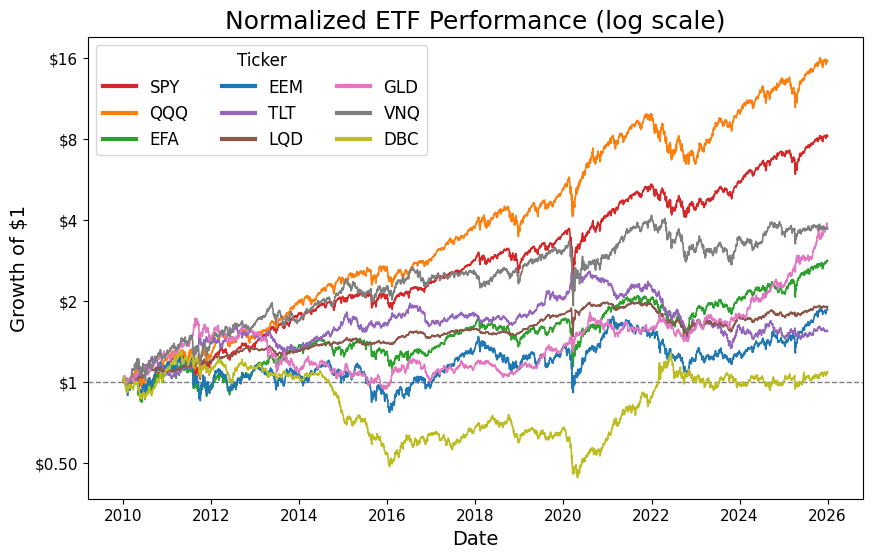

In [6]:
# Growth of $1 invested at the start of the sample
growth = prices / prices.iloc[0]

fig, ax = plt.subplots(figsize=(10, 6))

for ticker in tickers:
    ax.plot(growth.index, growth[ticker], label=ticker, color=ticker_colors[ticker], linewidth=1.2)

format_growth_axis(ax)

ax.set_title("Normalized ETF Performance (log scale)")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
thicken_legend_lines(ax.legend(title="Ticker", ncol=3))
plt.show()

## 3. Risk and Return Analysis

Historical daily returns are used to estimate annualized return, volatility, and cross-asset correlations. Correlation analysis helps identify diversification benefits across asset classes.

Estimates use daily observations and are reported in annual terms:

- **Arithmetic annual return** = mean daily return × 252. This is the expected-return input to mean-variance optimization.
- **Annualized volatility** = standard deviation of daily returns × √252.
- **CAGR** (compound annual growth rate), used in Sections 6–7, is the realized compounded growth rate. It differs from the arithmetic return for two reasons: volatility drags compounded growth down (by roughly half the variance), while compounding the average return pushes it up. CAGR can therefore be lower or slightly higher than the arithmetic figure.

In [7]:
# Annualized return and volatility (decimal units, used in later charts)
summary_stats = pd.DataFrame({
    "Arithmetic Annual Return": returns.mean() * TRADING_DAYS,
    "Annualized Volatility": returns.std() * np.sqrt(TRADING_DAYS)
})

(summary_stats * 100).add_suffix(" (%)").round(1)

,Arithmetic Annual Return (%),Annualized Volatility (%)
SPY,14.6,17.2
QQQ,19.3,20.6
EFA,8.2,18.4
EEM,6.1,21.3
TLT,3.8,15.1
LQD,4.3,7.7
GLD,9.4,15.8
VNQ,10.3,20.5
DBC,1.9,17.1


### 3.1 Asset Risk-Return Profile

The figure below compares the annualized return and volatility of each ETF, illustrating differences in historical risk and performance across asset classes.

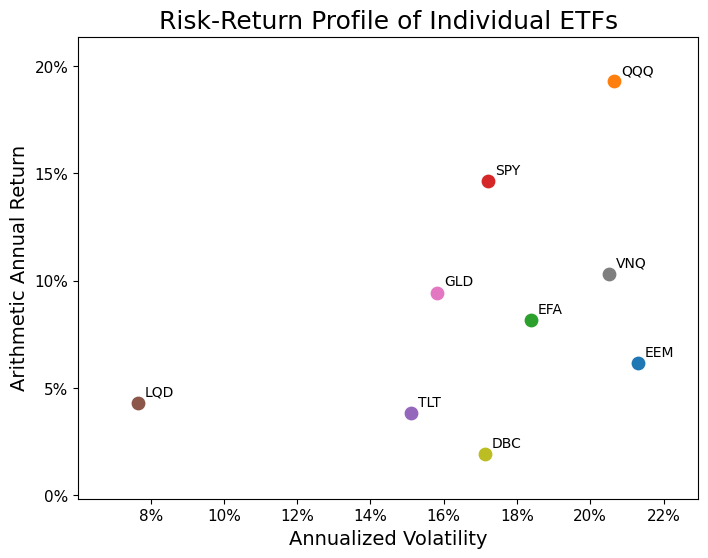

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

for ticker, row in summary_stats.iterrows():
    ax.scatter(
        row["Annualized Volatility"],
        row["Arithmetic Annual Return"],
        s=80,
        color=ticker_colors[ticker]
    )

    ax.annotate(
        ticker,
        (row["Annualized Volatility"], row["Arithmetic Annual Return"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

ax.margins(0.12)
format_percent_axes(ax, x=True, y=True)

ax.set_xlabel("Annualized Volatility")
ax.set_ylabel("Arithmetic Annual Return")
ax.set_title("Risk-Return Profile of Individual ETFs")
plt.show()

QQQ produced the highest historical return but also had high volatility, while LQD had substantially lower return and risk. DBC had the lowest return of the nine ETFs (1.9% a year), despite volatility similar to SPY's. Combining assets with different risk-return profiles may improve portfolio diversification.

### 3.2 Correlation

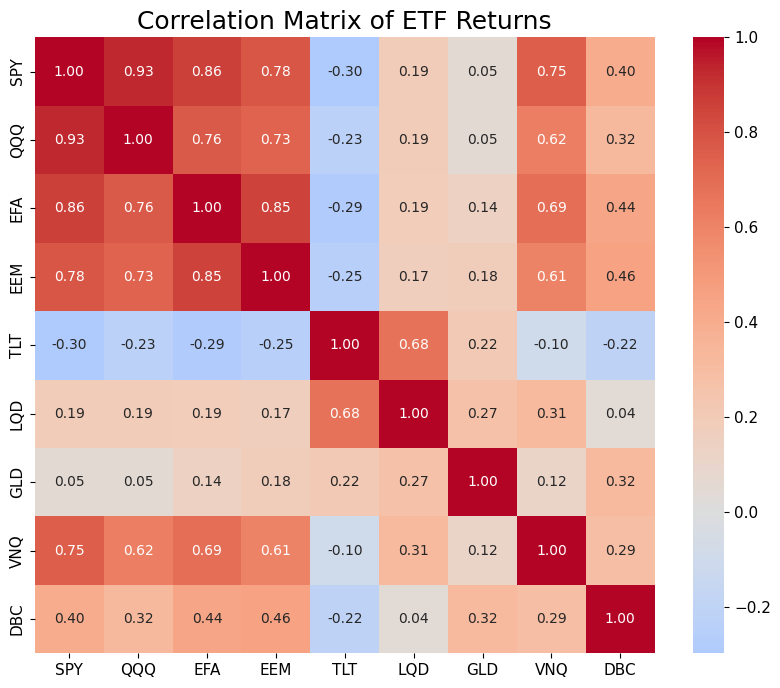

In [9]:
# Correlation matrix
corr = returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")

plt.title("Correlation Matrix of ETF Returns")
plt.show()

The correlation matrix highlights how different asset classes move relative to one another. Lower or negative correlations can reduce portfolio volatility because losses in one asset may be partially offset by gains or smaller losses in another.

## 4. Portfolio Theory

Portfolio performance depends on both asset weights and cross-asset relationships. Portfolio weights sum to 1, representing a fully invested portfolio. Expected return is determined by weighted asset returns, while portfolio risk also depends on the covariance between assets.

The functions below work in daily units, because estimation and backtesting use daily observations. Results are annualized for reporting.

### 4.1 Portfolio Return

The expected portfolio return is calculated as the weighted average of each asset's expected return:

$$
R_p = w^T \mu
$$

where $w$ is the vector of portfolio weights and $\mu$ is the vector of average asset returns.

In [10]:
def portfolio_return(weights, returns):
    """
    Compute expected daily portfolio return.

    weights: array of portfolio weights
    returns: DataFrame of daily asset returns
    """
    return returns.mean() @ weights

### 4.2 Portfolio Volatility

Portfolio volatility measures the risk of the combined portfolio. Unlike return, volatility is not simply the weighted average of individual volatilities because asset co-movement matters.

$$
\sigma_p = \sqrt{w^T \Sigma w}
$$

where $\Sigma$ is the covariance matrix of asset returns.

In [11]:
def portfolio_volatility(weights, cov_matrix):
    """
    Compute daily portfolio volatility.

    weights: array of portfolio weights
    cov_matrix: covariance matrix of daily asset returns
    """
    return np.sqrt(weights.T @ cov_matrix @ weights)

### 4.3 Equal-Weight Portfolio

As a baseline, an equal-weight portfolio allocates the same fraction of capital to each ETF. This provides a simple benchmark before applying optimization.

In [12]:
equal_weights = np.ones(n_assets) / n_assets
cov_matrix = returns.cov()

equal_return = portfolio_return(equal_weights, returns) * TRADING_DAYS
equal_volatility = portfolio_volatility(equal_weights, cov_matrix) * np.sqrt(TRADING_DAYS)

print("Equal-weight portfolio")
print(f"Arithmetic annual return: {equal_return:.2%}")
print(f"Annualized volatility: {equal_volatility:.2%}")

Equal-weight portfolio
Arithmetic annual return: 8.67%
Annualized volatility: 11.22%


### 4.4 Diversification Effect

A weighted average of individual asset volatilities ignores covariance. When assets are not perfectly correlated, portfolio volatility can be lower than this naive estimate.

In [13]:
naive_volatility = equal_weights @ summary_stats["Annualized Volatility"]

portfolio_theory_summary = pd.DataFrame(
    {
        "Value (%)": [
            equal_return,
            naive_volatility,
            equal_volatility,
            naive_volatility - equal_volatility
        ]
    },
    index=[
        "Arithmetic Annual Return",
        "Naive Volatility (weighted average)",
        "Portfolio Volatility",
        "Diversification Benefit (pp)"
    ]
) * 100

portfolio_theory_summary.round(2)

,Value (%)
Arithmetic Annual Return,8.67
Naive Volatility (weighted average),17.08
Portfolio Volatility,11.22
Diversification Benefit (pp),5.87


The equal-weight portfolio's volatility (11.2%) is well below the weighted average of the individual ETF volatilities (17.1%). This diversification benefit of about 5.9 percentage points comes from imperfect correlations.

## 5. Portfolio Optimization

### 5.1 Unconstrained Optimization

This section first examines unconstrained mean-variance optimization using classical Modern Portfolio Theory techniques. These unconstrained portfolios serve as a baseline for understanding how optimization behaves when allocations are determined purely by historical return and covariance estimates.

The analysis focuses on two classical optimization approaches:

- Minimum Variance Portfolio
- Maximum Sharpe Ratio Portfolio

The efficient frontier is then constructed to visualize the tradeoff between portfolio risk and expected return across feasible portfolios.

Optimization uses daily estimates of mean returns and covariance. The resulting portfolios are reported as arithmetic annual return, annualized volatility, and Sharpe ratio (defined below). All of these are in-sample estimates.

#### Portfolio Constraints

The baseline portfolios are long-only and fully invested:

- Portfolio weights sum to 1
- Short selling is not allowed
- Individual weights range from 0% to 100%

Here, "unconstrained" refers to the absence of additional diversification bounds.

Every optimization is checked before its weights are used. The solver must report success, and the weights must sum to one and respect the bounds, within a tolerance of 1e-6.

SLSQP's default stopping tolerance (`ftol = 1e-6`) is loose relative to daily volatilities of around 0.01. In testing, it overstated some efficient-frontier volatilities by more than 0.1 percentage points, which produced visible kinks. A tighter tolerance (`ftol = 1e-12`) is therefore used for every optimization; no solves failed because of it.

In [14]:
constraints = {
    "type": "eq",
    "fun": lambda w: np.sum(w) - 1
}

bounds = [(0, 1)] * n_assets

initial_guess = np.ones(n_assets) / n_assets

SOLVER_OPTIONS = {"ftol": 1e-12, "maxiter": 1000}


def is_feasible(weights, bounds, tol=1e-6):
    lower, upper = np.array(bounds).T
    return bool(
        np.all(np.isfinite(weights))
        and abs(weights.sum() - 1) <= tol
        and np.all(weights >= lower - tol)
        and np.all(weights <= upper + tol)
    )


def optimize_weights(objective, args, bounds, extra_constraints=(), x0=None):
    """
    Run SLSQP and return (weights, ok, message).

    ok is True only if the solver succeeded and the weights are feasible. Feasible
    weights are clipped to the bounds to remove numerical noise such as -1e-17.
    """
    result = minimize(
        objective,
        initial_guess if x0 is None else x0,
        args=args,
        method="SLSQP",
        bounds=bounds,
        constraints=[constraints, *extra_constraints],
        options=SOLVER_OPTIONS
    )

    ok = bool(result.success) and is_feasible(result.x, bounds)
    weights = result.x

    if ok:
        lower, upper = np.array(bounds).T
        weights = np.clip(weights, lower, upper)
        weights = weights / weights.sum()

    return weights, ok, result.message


def require_weights(objective, args, bounds):
    weights, ok, message = optimize_weights(objective, args, bounds)
    if not ok:
        raise RuntimeError(f"Optimization failed or returned infeasible weights: {message}")
    return weights


def expected_profile(weights):
    """In-sample arithmetic annual return, annualized volatility, and Sharpe ratio."""
    annual_return = portfolio_return(weights, returns) * TRADING_DAYS
    annual_volatility = portfolio_volatility(weights, cov_matrix) * np.sqrt(TRADING_DAYS)
    return pd.Series({
        "Arithmetic Annual Return": annual_return,
        "Annualized Volatility": annual_volatility,
        "Sharpe Ratio": (annual_return - RISK_FREE_RATE) / annual_volatility
    })


def print_profile(name, weights):
    profile = expected_profile(weights)
    print(name)
    print(f"Arithmetic annual return: {profile['Arithmetic Annual Return']:.2%}")
    print(f"Annualized volatility: {profile['Annualized Volatility']:.2%}")
    print(f"Sharpe ratio: {profile['Sharpe Ratio']:.2f}")


def weight_table(weights_by_portfolio):
    """Allocation table in percent, one column per portfolio, rows in ticker order."""
    return (pd.DataFrame(weights_by_portfolio, index=tickers) * 100).round(1)


def percent_columns(table, columns):
    """Express the listed decimal columns in percent and label them with (%)."""
    table = table.copy()
    table[columns] = table[columns] * 100
    return table.rename(columns={c: f"{c} (%)" for c in columns})

#### Minimum Variance Portfolio

The minimum variance portfolio identifies the allocation with the lowest possible portfolio volatility regardless of return expectations.

The optimization problem is:

$$
\min_w \sqrt{w^T \Sigma w}
$$

subject to the portfolio constraints.

In [15]:
min_var_weights = require_weights(portfolio_volatility, (cov_matrix,), bounds)

weight_table({"Weight (%)": min_var_weights})

,Weight (%)
SPY,5.1
QQQ,0.0
EFA,0.0
EEM,0.0
TLT,0.0
LQD,78.0
GLD,5.1
VNQ,0.0
DBC,11.8


In [16]:
print_profile("Minimum Variance Portfolio", min_var_weights)

Minimum Variance Portfolio
Arithmetic annual return: 4.80%
Annualized volatility: 7.03%
Sharpe ratio: 0.68


The minimum variance portfolio places 78% in LQD because the objective only minimizes volatility. It does not try to maximize return, so it favors stable bond exposure over higher-return but more volatile assets.

#### Maximum Sharpe Ratio Portfolio

The Sharpe ratio measures excess return earned per unit of risk. It is computed from daily excess returns and annualized:

$$
\text{Sharpe Ratio} = \sqrt{252}\,\frac{\operatorname{mean}(r_p - r_f)}{\operatorname{std}(r_p - r_f)}
$$

For simplicity, the risk-free rate $r_f$ is assumed to be zero throughout this analysis. Under that assumption, the Sharpe ratio equals the arithmetic annual return divided by annualized volatility. The same definition is used for optimization here and for evaluating realized performance in Sections 6–7.

The maximum Sharpe portfolio seeks the allocation with the highest risk-adjusted return.

In [17]:
def negative_sharpe(weights, returns, cov_matrix):
    """Negative daily Sharpe ratio. Annualizing multiplies it by a constant, so the optimal weights are unchanged."""
    excess_return = portfolio_return(weights, returns) - RISK_FREE_RATE / TRADING_DAYS
    return -(excess_return / portfolio_volatility(weights, cov_matrix))

In [18]:
max_sharpe_weights = require_weights(negative_sharpe, (returns, cov_matrix), bounds)

weight_table({"Weight (%)": max_sharpe_weights})

,Weight (%)
SPY,4.3
QQQ,43.1
EFA,0.0
EEM,0.0
TLT,24.9
LQD,0.0
GLD,27.7
VNQ,0.0
DBC,0.0


In [19]:
print_profile("Maximum Sharpe Portfolio", max_sharpe_weights)

Maximum Sharpe Portfolio
Arithmetic annual return: 12.51%
Annualized volatility: 10.95%
Sharpe ratio: 1.14


The maximum Sharpe portfolio is concentrated in QQQ (43%), GLD (28%), and TLT (25%), and five of the nine ETFs receive zero weight. The result shows how historical mean-variance optimization can produce concentrated allocations when estimated risk-adjusted returns differ across assets.

#### Efficient Frontier

The efficient frontier represents the set of portfolios that achieve the highest expected return for each level of risk.

For a target return level, the optimization problem minimizes portfolio volatility subject to achieving the desired return. Targets run from the minimum variance portfolio's return up to the highest return attainable under the bounds. That maximum is found by solving a linear program. Each solve is warm-started from the previous solution, and any failed targets are reported.

In [20]:
def max_feasible_return(bounds):
    """Highest expected daily return attainable under the bounds, and the weights that attain it."""
    result = linprog(
        -returns.mean().values,
        A_eq=np.ones((1, n_assets)),
        b_eq=[1],
        bounds=bounds,
        method="highs"
    )
    if not result.success:
        raise RuntimeError(f"Maximum-return linear program failed: {result.message}")
    return -result.fun, result.x


def efficient_frontier(bounds, start_return, n_points=50, label="Frontier"):
    max_return, max_return_weights = max_feasible_return(bounds)
    target_returns = np.linspace(start_return, max_return, n_points)

    frontier_returns, frontier_volatilities, failures = [], [], []
    x0 = initial_guess

    for target_return in target_returns:
        target_constraint = {
            "type": "eq",
            "fun": lambda w, target_return=target_return: portfolio_return(w, returns) - target_return
        }

        weights, ok, message = optimize_weights(
            portfolio_volatility,
            (cov_matrix,),
            bounds,
            extra_constraints=[target_constraint],
            x0=x0
        )

        # Also require the target return to be met (1e-7 daily, about 0.003% a year)
        if ok and abs(portfolio_return(weights, returns) - target_return) <= 1e-7:
            frontier_returns.append(portfolio_return(weights, returns))
            frontier_volatilities.append(portfolio_volatility(weights, cov_matrix))
            x0 = weights
        else:
            failures.append((target_return * TRADING_DAYS, message if not ok else "target return not met"))

    print(
        f"{label}: {n_points - len(failures)}/{n_points} targets solved, "
        f"from {start_return * TRADING_DAYS:.2%} to the maximum feasible return of {max_return * TRADING_DAYS:.2%}"
    )
    for target, message in failures:
        print(f"  Failed target {target:.2%}: {message}")

    return np.array(frontier_returns), np.array(frontier_volatilities), max_return_weights

In [21]:
min_var_daily_return = portfolio_return(min_var_weights, returns)

frontier_returns, frontier_volatilities, max_return_weights = efficient_frontier(
    bounds,
    min_var_daily_return,
    label="Unconstrained frontier"
)

Unconstrained frontier: 50/50 targets solved, from 4.80% to the maximum feasible return of 19.28%


To visualize the feasible portfolio space, 30,000 random long-only portfolios are generated. Their weights are drawn uniformly over all fully invested allocations, using a Dirichlet distribution with every parameter equal to one. The draws use their own seeded random generator, so the cloud is reproducible and does not consume random numbers from the bootstrap in Section 8.

In [22]:
cloud_rng = np.random.default_rng(2010)
n_random_portfolios = 30000

random_weights = cloud_rng.dirichlet(np.ones(n_assets), size=n_random_portfolios)

random_returns = random_weights @ returns.mean().values * TRADING_DAYS
random_volatilities = np.sqrt(
    np.einsum("ij,jk,ik->i", random_weights, cov_matrix.values, random_weights) * TRADING_DAYS
)
random_sharpes = (random_returns - RISK_FREE_RATE) / random_volatilities

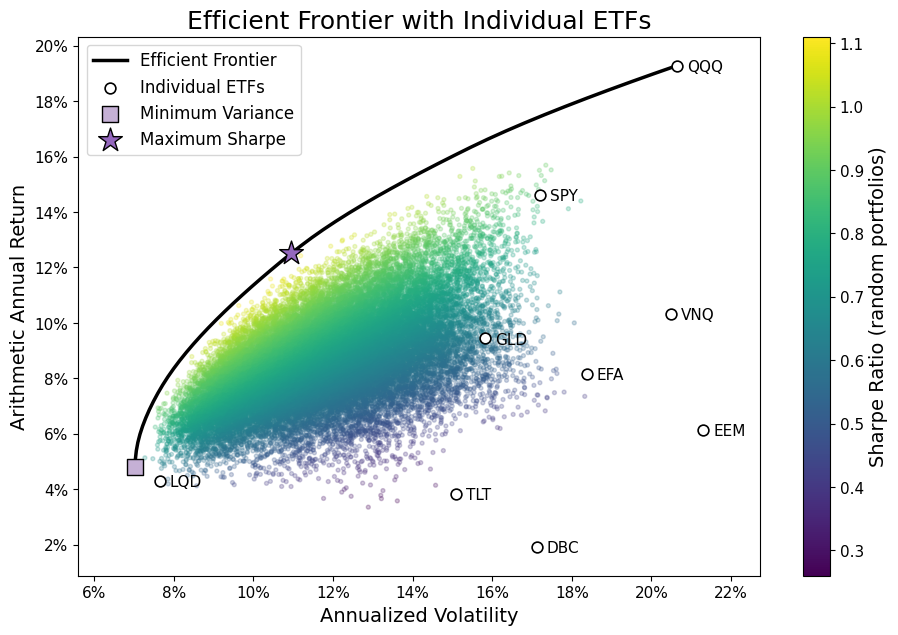

In [23]:
fig, ax = plt.subplots(figsize=(11, 7))

cloud = ax.scatter(
    random_volatilities,
    random_returns,
    c=random_sharpes,
    cmap="viridis",
    alpha=0.25,
    s=8,
    zorder=1
)

ax.plot(
    frontier_volatilities * np.sqrt(TRADING_DAYS),
    frontier_returns * TRADING_DAYS,
    color="black",  # neutral, so it is not read as part of the Sharpe color scale
    linewidth=2.5,
    label="Efficient Frontier",
    zorder=2
)

ax.scatter(
    summary_stats["Annualized Volatility"],
    summary_stats["Arithmetic Annual Return"],
    s=60,
    marker="o",
    facecolor="white",
    edgecolor="black",
    linewidth=1.2,
    label="Individual ETFs",
    zorder=3
)

for ticker, row in summary_stats.iterrows():
    ax.annotate(
        ticker,
        (row["Annualized Volatility"], row["Arithmetic Annual Return"]),
        xytext=(7, -4),
        textcoords="offset points",
        fontsize=11,
        zorder=5
    )

min_var_profile = expected_profile(min_var_weights)
max_sharpe_profile = expected_profile(max_sharpe_weights)

ax.scatter(
    min_var_profile["Annualized Volatility"],
    min_var_profile["Arithmetic Annual Return"],
    s=portfolio_styles["Unconstrained Min Variance"]["s"],
    marker=portfolio_styles["Unconstrained Min Variance"]["marker"],
    color=portfolio_styles["Unconstrained Min Variance"]["color"],
    edgecolor="black",
    label="Minimum Variance",
    zorder=4
)

ax.scatter(
    max_sharpe_profile["Annualized Volatility"],
    max_sharpe_profile["Arithmetic Annual Return"],
    s=portfolio_styles["Unconstrained Max Sharpe"]["s"],
    marker=portfolio_styles["Unconstrained Max Sharpe"]["marker"],
    color=portfolio_styles["Unconstrained Max Sharpe"]["color"],
    edgecolor="black",
    label="Maximum Sharpe",
    zorder=4
)

ax.margins(x=0.1, y=0.06)  # extra horizontal room so edge labels such as EEM stay inside
format_percent_axes(ax, x=True, y=True)

ax.set_xlabel("Annualized Volatility")
ax.set_ylabel("Arithmetic Annual Return")
ax.set_title("Efficient Frontier with Individual ETFs")

colorbar_scale = plt.cm.ScalarMappable(norm=cloud.norm, cmap=cloud.cmap)
fig.colorbar(colorbar_scale, ax=ax, label="Sharpe Ratio (random portfolios)")
ax.legend(loc="upper left")

fig.savefig(IMAGE_DIR / "efficient_frontier.png", dpi=150, bbox_inches="tight")
plt.show()

The random portfolios illustrate the feasible risk-return space, while the efficient frontier identifies the highest expected return available at each level of volatility. The minimum variance portfolio lies at the lowest-risk point, and the maximum Sharpe portfolio identifies the strongest estimated risk-adjusted allocation.

The individual ETFs are plotted using the same arithmetic return and volatility estimates as the frontier. QQQ sits at the frontier's upper end, because a 100% QQQ portfolio has the highest attainable expected return. Every other ETF lies inside the frontier, meaning some frontier portfolio offers both a higher expected return and lower volatility.

### 5.2 Constrained Optimization

Additional allocation bounds are introduced to limit concentration:

- Minimum asset weight: 5%
- Maximum asset weight: 35%

The constrained portfolios are compared with the baseline solutions to measure the cost of greater diversification.

In [24]:
bounds_constrained = [(0.05, 0.35)] * n_assets

#### Constrained Minimum Variance

In [25]:
constrained_min_var_weights = require_weights(portfolio_volatility, (cov_matrix,), bounds_constrained)

weight_table({"Weight (%)": constrained_min_var_weights})

,Weight (%)
SPY,5.0
QQQ,5.0
EFA,5.0
EEM,5.0
TLT,22.2
LQD,35.0
GLD,7.3
VNQ,5.0
DBC,10.5


In [26]:
print_profile("Constrained Minimum Variance Portfolio", constrained_min_var_weights)

Constrained Minimum Variance Portfolio
Arithmetic annual return: 6.16%
Annualized volatility: 7.93%
Sharpe ratio: 0.78


With the bounds, LQD is capped at 35%. Most of the freed weight goes to TLT (0% → 22%) and to the four ETFs raised from zero to the 5% minimum (QQQ, EFA, EEM, and VNQ). Compared with the unconstrained minimum variance portfolio, volatility rises from 7.03% to 7.93% in exchange for exposure to every ETF.

#### Constrained Maximum Sharpe

In [27]:
constrained_max_sharpe_weights = require_weights(negative_sharpe, (returns, cov_matrix), bounds_constrained)

weight_table({"Weight (%)": constrained_max_sharpe_weights})

,Weight (%)
SPY,5.0
QQQ,29.8
EFA,5.0
EEM,5.0
TLT,19.6
LQD,5.0
GLD,20.6
VNQ,5.0
DBC,5.0


In [28]:
print_profile("Constrained Maximum Sharpe Portfolio", constrained_max_sharpe_weights)

Constrained Maximum Sharpe Portfolio
Arithmetic annual return: 10.71%
Annualized volatility: 10.60%
Sharpe ratio: 1.01


Under the bounds, the maximum Sharpe portfolio still leans toward QQQ (30%), GLD (21%), and TLT (20%), while the other six ETFs sit at the 5% minimum. The estimated Sharpe ratio falls from 1.14 to 1.01, reflecting the practical tradeoff between maximizing historical efficiency and limiting concentration risk.

#### Constrained Efficient Frontier

The efficient frontier can also be constructed under the allocation constraints introduced above. Comparing the constrained and unconstrained frontiers illustrates the cost of imposing diversification requirements.

Because the optimizer has less flexibility, the constrained frontier lies below the unconstrained frontier, and it also ends at a lower maximum return. The constrained targets run from the constrained minimum variance return up to the highest return the bounds allow.

In [29]:
constrained_frontier_returns, constrained_frontier_volatilities, constrained_max_return_weights = efficient_frontier(
    bounds_constrained,
    portfolio_return(constrained_min_var_weights, returns),
    label="Constrained frontier"
)

weight_table({
    "Max-Return Weights, Unconstrained (%)": max_return_weights,
    "Max-Return Weights, Constrained (%)": constrained_max_return_weights
})

Constrained frontier: 50/50 targets solved, from 6.16% to the maximum feasible return of 13.34%


,"Max-Return Weights, Unconstrained (%)","Max-Return Weights, Constrained (%)"
SPY,0.0,30.0
QQQ,100.0,35.0
EFA,0.0,5.0
EEM,0.0,5.0
TLT,0.0,5.0
LQD,0.0,5.0
GLD,0.0,5.0
VNQ,0.0,5.0
DBC,0.0,5.0


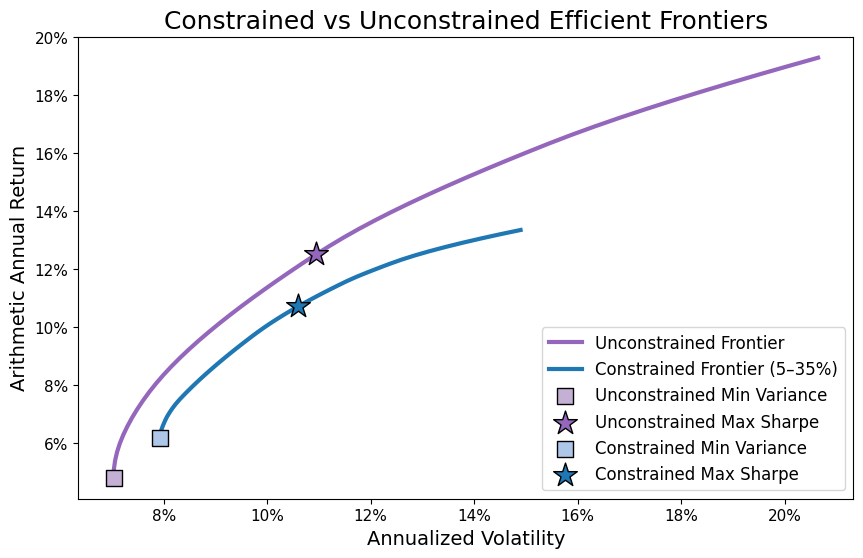

In [30]:
optimized_weights_by_name = {
    "Unconstrained Min Variance": min_var_weights,
    "Unconstrained Max Sharpe": max_sharpe_weights,
    "Constrained Min Variance": constrained_min_var_weights,
    "Constrained Max Sharpe": constrained_max_sharpe_weights
}

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    frontier_volatilities * np.sqrt(TRADING_DAYS),
    frontier_returns * TRADING_DAYS,
    color=FAMILY_COLORS["unconstrained"],
    linewidth=3,
    label="Unconstrained Frontier"
)

ax.plot(
    constrained_frontier_volatilities * np.sqrt(TRADING_DAYS),
    constrained_frontier_returns * TRADING_DAYS,
    color=FAMILY_COLORS["constrained"],
    linewidth=3,
    label="Constrained Frontier (5–35%)"
)

for name, weights in optimized_weights_by_name.items():
    profile = expected_profile(weights)
    style = portfolio_styles[name]
    ax.scatter(
        profile["Annualized Volatility"],
        profile["Arithmetic Annual Return"],
        s=style["s"],
        marker=style["marker"],
        color=style["color"],
        edgecolor="black",
        label=name,
        zorder=3
    )

ax.margins(0.05)
format_percent_axes(ax, x=True, y=True)

ax.set_xlabel("Annualized Volatility")
ax.set_ylabel("Arithmetic Annual Return")
ax.set_title("Constrained vs Unconstrained Efficient Frontiers")

ax.legend(loc="lower right")
plt.show()

The constrained frontier lies below the unconstrained frontier. It ends at 13.34%, the highest return attainable with no ETF above 35% and none below 5% (35% QQQ, 30% SPY, and 5% in each of the rest). The allocation bounds reduce estimated in-sample efficiency but rule out the most concentrated portfolios.

### 5.3 Optimization Comparison

In [31]:
optimized_weights = {
    "Unconstrained Min Variance": min_var_weights,
    "Constrained Min Variance": constrained_min_var_weights,
    "Unconstrained Max Sharpe": max_sharpe_weights,
    "Constrained Max Sharpe": constrained_max_sharpe_weights
}

allocation_table = weight_table(optimized_weights)
allocation_table.index.name = "Allocation (%)"

allocation_table

,Unconstrained Min Variance,Constrained Min Variance,Unconstrained Max Sharpe,Constrained Max Sharpe
Allocation (%),,,,
SPY,5.1,5.0,4.3,5.0
QQQ,0.0,5.0,43.1,29.8
EFA,0.0,5.0,0.0,5.0
EEM,0.0,5.0,0.0,5.0
TLT,0.0,22.2,24.9,19.6
LQD,78.0,35.0,0.0,5.0
GLD,5.1,7.3,27.7,20.6
VNQ,0.0,5.0,0.0,5.0
DBC,11.8,10.5,0.0,5.0


In [32]:
optimization_comparison = pd.DataFrame(
    {name: expected_profile(weights) for name, weights in optimized_weights.items()}
).T

optimization_comparison = percent_columns(
    optimization_comparison,
    ["Arithmetic Annual Return", "Annualized Volatility"]
)

optimization_comparison.round(2)

,Arithmetic Annual Return (%),Annualized Volatility (%),Sharpe Ratio
Unconstrained Min Variance,4.80,7.03,0.68
Constrained Min Variance,6.16,7.93,0.78
Unconstrained Max Sharpe,12.51,10.95,1.14
Constrained Max Sharpe,10.71,10.60,1.01


The bounds reduce the maximum Sharpe ratio from 1.14 to 1.01 but spread the allocation across all nine ETFs.

For minimum variance, the bounds raise volatility (7.03% → 7.93%) but also raise the Sharpe ratio (0.68 → 0.78). The minimum variance objective ignores expected returns, so forcing some weight into higher-return assets happens to improve return per unit of risk in this sample.

These are in-sample estimates: the same data are used to choose the weights and to evaluate them. The next sections examine robustness in two different ways:

- **Section 7** runs a rolling backtest. Each allocation is estimated only from the observations that precede it, and is then held over the following period.
- **Section 8** uses the bootstrap. It resamples the full 2010–2025 dataset to measure how sensitive the optimized weights are to estimation error. This is a sensitivity analysis, not an out-of-sample test.

## 6. In-Sample Performance Evaluation

The portfolios from Section 5 are evaluated over the same 2010–2025 sample used to estimate them. These results are therefore **in-sample**: the weights were chosen with knowledge of the returns being evaluated, so they overstate what an investor could have achieved in real time.

Each portfolio except SPY, including equal weight, is held as a constant mix, rebalanced daily to its target weights. This matches the optimizer's assumption, so realized volatility and Sharpe ratios equal the expected values in Section 5.3. SPY is a single asset held throughout.

Metrics:

- **CAGR**: realized compound annual growth rate
- **Annualized volatility**: standard deviation of daily returns × √252
- **Sharpe ratio**: √252 × mean daily excess return / standard deviation of daily excess return, with $r_f = 0$
- **Maximum drawdown**: the largest peak-to-trough decline in cumulative value, with the initial investment counted as the first peak

### 6.1 Performance Metrics

In [33]:
def cagr(port_returns, periods_per_year=TRADING_DAYS):
    growth = (1 + port_returns).prod()
    n_periods = len(port_returns)

    return growth ** (periods_per_year / n_periods) - 1


def annualized_volatility(port_returns, periods_per_year=TRADING_DAYS):
    return port_returns.std() * np.sqrt(periods_per_year)


def sharpe_ratio(port_returns, risk_free_rate=RISK_FREE_RATE, periods_per_year=TRADING_DAYS):
    excess_returns = port_returns - risk_free_rate / periods_per_year

    return np.sqrt(periods_per_year) * excess_returns.mean() / excess_returns.std()


def drawdown_series(port_returns):
    cumulative = (1 + port_returns).cumprod()
    running_max = cumulative.cummax().clip(lower=1)  # the initial $1 counts as the first peak

    return cumulative / running_max - 1


def max_drawdown(port_returns):
    return drawdown_series(port_returns).min()


def performance_table(return_series):
    table = pd.DataFrame({
        name: {
            "CAGR": cagr(port_returns),
            "Annualized Volatility": annualized_volatility(port_returns),
            "Sharpe Ratio": sharpe_ratio(port_returns),
            "Maximum Drawdown": max_drawdown(port_returns)
        }
        for name, port_returns in return_series.items()
    }).T

    return percent_columns(table, ["CAGR", "Annualized Volatility", "Maximum Drawdown"])

In [34]:
portfolio_return_series = {
    "Equal Weight (daily rebalance)": returns @ equal_weights,
    "Unconstrained Min Variance": returns @ min_var_weights,
    "Constrained Min Variance": returns @ constrained_min_var_weights,
    "Unconstrained Max Sharpe": returns @ max_sharpe_weights,
    "Constrained Max Sharpe": returns @ constrained_max_sharpe_weights,
    "SPY Buy-and-Hold": returns["SPY"]
}

In [35]:
performance_summary = performance_table(portfolio_return_series)

performance_summary.round(2)

,CAGR (%),Annualized Volatility (%),Sharpe Ratio,Maximum Drawdown (%)
Equal Weight (daily rebalance),8.37,11.22,0.77,-22.85
Unconstrained Min Variance,4.66,7.03,0.68,-20.61
Constrained Min Variance,6.02,7.93,0.78,-22.94
Unconstrained Max Sharpe,12.64,10.95,1.14,-27.32
Constrained Max Sharpe,10.68,10.60,1.01,-24.73
SPY Buy-and-Hold,14.05,17.21,0.85,-33.72


Volatility and Sharpe ratios match Section 5.3, because each portfolio is held as a constant mix over the sample used to estimate it. CAGR differs slightly from the arithmetic return, as described in Section 3.

The unconstrained maximum Sharpe portfolio has the strongest in-sample risk-adjusted performance (Sharpe ratio 1.14). It also has a deeper drawdown (−27.3%) than the minimum variance and equal-weight portfolios. SPY produces the highest CAGR (14.0%) but also the highest volatility and deepest drawdown (−33.7%).

Because these weights were chosen with hindsight, the in-sample results are an optimistic benchmark rather than an estimate of achievable performance.

### 6.2 Cumulative Portfolio Performance

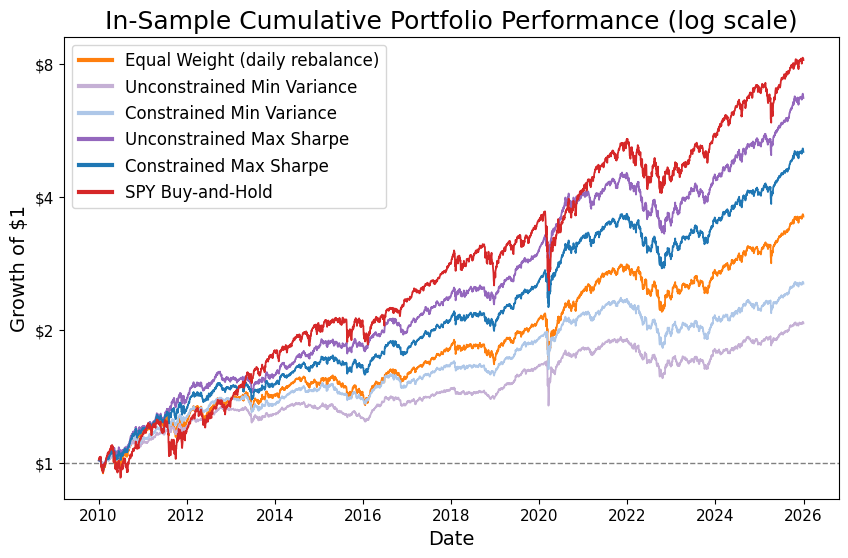

In [36]:
fig, ax = plt.subplots(figsize=(10, 6))

for name, port_returns in portfolio_return_series.items():
    style = portfolio_styles[name]
    ax.plot(
        (1 + port_returns).cumprod(),
        label=name,
        color=style["color"],
        linewidth=1.3
    )

format_growth_axis(ax)

ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
ax.set_title("In-Sample Cumulative Portfolio Performance (log scale)")

thicken_legend_lines(ax.legend())
plt.show()

SPY achieves the highest cumulative growth, while the unconstrained maximum Sharpe portfolio performs best among the optimized portfolios. The minimum variance portfolios (lighter shades) grow more slowly but experience smaller fluctuations. On the log scale, equal vertical distances represent equal percentage changes.

These results are in-sample because the portfolio weights were estimated using the full historical dataset. The next section evaluates the strategies using a rolling out-of-sample backtest.

## 7. Rolling Out-of-Sample Backtest

The previous section evaluates static portfolios estimated using the full historical sample. This section instead uses a rolling out-of-sample backtest, in which each allocation is estimated only from returns observed before it takes effect.

Conventions:

- **Information:** At each rebalance, expected returns and covariance are estimated from the previous two years (504 trading days) of daily returns. The window ends with the return to the most recent close, and no later data are used.
- **Execution (idealized):** The new weights are assumed to be traded at that same closing price, so the first return they earn is the following day's.
  - This is an idealized closing-price execution assumption. It treats computing the weights and trading as instantaneous at the close.
  - In practice, there would be some delay between observing the close and trading. That delay is not modeled.
- **Holdings:** Portfolios are rebalanced to their target weights every 21 trading days.
  - The 5–35% bounds apply to these target weights.
  - Between rebalances, holdings drift with asset returns, so actual weights can move outside the bounds.
- **Strategies:** The constrained (5–35%) and unconstrained maximum Sharpe strategies are compared with an equal-weight portfolio. Equal weight is reset to 1/9 in each ETF on the same 21-day schedule and also drifts in between. SPY is held as a buy-and-hold benchmark.
- **Optimizer failures:** If an optimization fails or returns infeasible weights, the current holdings are kept (no trade) and no return dates are dropped. If the first optimization fails, the portfolio starts from equal weights, which satisfy both sets of bounds.
- **Turnover:** One-way turnover at a rebalance is ½ × Σ |target weight − drifted weight|. The initial purchase is excluded. Annual turnover is total turnover divided by the number of years.
- **Costs:** The main results are gross of transaction costs. Section 7.2 deducts proportional costs of 10 and 25 basis points per dollar traded.

All strategies are evaluated over exactly the same dates, which are also the dates of the in-sample analysis in Sections 3–6.

### 7.1 Rolling Maximum Sharpe Strategies

In [37]:
# Full return history; 2008-2009 returns feed the early rolling estimation windows
backtest_returns = all_returns

assert list(backtest_returns.columns) == tickers

In [38]:
evaluation_start = ANALYSIS_START
window = 2 * TRADING_DAYS
rebalance_freq = 21


def run_rolling_backtest(target_weights_fn, asset_returns=backtest_returns):
    """
    Rebalance to target weights every rebalance_freq days and let holdings drift in between.

    target_weights_fn(past_returns) returns (weights, ok). If ok is False, the current
    holdings are kept (no trade); if the first rebalance fails, the portfolio starts
    from equal weights. Returns gross daily portfolio returns and a rebalance log that
    records the amount traded at each rebalance.
    """
    start_idx = asset_returns.index.searchsorted(evaluation_start)
    if start_idx < window:
        raise ValueError("Not enough history for the first estimation window")

    holdings = None
    daily_returns = []
    rebalance_log = []

    for i in range(start_idx, len(asset_returns), rebalance_freq):
        past_returns = asset_returns.iloc[i - window:i]
        target_weights, ok = target_weights_fn(past_returns)

        if ok:
            new_holdings = target_weights
        elif holdings is None:
            new_holdings = equal_weights
        else:
            new_holdings = holdings

        # Pre-trade weights: drifted holdings, or all cash before the initial purchase
        pre_trade = np.zeros(n_assets) if holdings is None else holdings
        amount_traded = np.abs(new_holdings - pre_trade).sum()

        # One-way turnover excludes the initial purchase
        turnover = 0.0 if holdings is None else 0.5 * amount_traded

        rebalance_log.append({
            "Date": asset_returns.index[i],
            "Optimizer Success": ok,
            "Turnover": turnover,
            "Amount Traded": amount_traded,
            **dict(zip(tickers, new_holdings))
        })

        # Value of $1 allocated at the rebalance, letting each asset compound
        period_returns = asset_returns.iloc[i:i + rebalance_freq]
        asset_growth = (1 + period_returns).cumprod().values
        portfolio_value = asset_growth @ new_holdings

        daily_returns.append(pd.Series(
            portfolio_value / np.r_[1, portfolio_value[:-1]] - 1,
            index=period_returns.index
        ))

        # Drifted weights at the end of the holding period
        holdings = new_holdings * asset_growth[-1] / portfolio_value[-1]

    return pd.concat(daily_returns), pd.DataFrame(rebalance_log).set_index("Date")


def max_sharpe_target(bounds):
    def target_weights_fn(past_returns):
        weights, ok, _ = optimize_weights(
            negative_sharpe,
            (past_returns, past_returns.cov()),
            bounds
        )
        return weights, ok

    return target_weights_fn


def equal_weight_target(past_returns):
    return equal_weights, True

In [39]:
assert is_feasible(equal_weights, bounds) and is_feasible(equal_weights, bounds_constrained)

constrained_rolling_returns, constrained_rolling_log = run_rolling_backtest(max_sharpe_target(bounds_constrained))
unconstrained_rolling_returns, unconstrained_rolling_log = run_rolling_backtest(max_sharpe_target(bounds))
equal_weight_returns, equal_weight_log = run_rolling_backtest(equal_weight_target)

evaluation_index = constrained_rolling_returns.index

assert evaluation_index.equals(unconstrained_rolling_returns.index)
assert evaluation_index.equals(equal_weight_returns.index)
assert evaluation_index.equals(returns.index)  # same dates as the in-sample analysis

spy_returns = backtest_returns.loc[evaluation_index, "SPY"]

print(f"Evaluation period: {evaluation_index[0].date()} to {evaluation_index[-1].date()} ({len(evaluation_index):,} trading days)")

for name, log in [("Constrained", constrained_rolling_log), ("Unconstrained", unconstrained_rolling_log)]:
    print(f"{name} max Sharpe: {(~log['Optimizer Success']).sum()} optimizer failures in {len(log)} rebalances")

Evaluation period: 2010-01-04 to 2025-12-31 (4,024 trading days)
Constrained max Sharpe: 0 optimizer failures in 192 rebalances
Unconstrained max Sharpe: 0 optimizer failures in 192 rebalances


In [40]:
rolling_performance = {
    "Rolling Constrained Max Sharpe": constrained_rolling_returns,
    "Rolling Unconstrained Max Sharpe": unconstrained_rolling_returns,
    "Equal Weight (21-day rebalance)": equal_weight_returns,
    "SPY Buy-and-Hold": spy_returns
}

rebalance_logs = {
    "Rolling Constrained Max Sharpe": constrained_rolling_log,
    "Rolling Unconstrained Max Sharpe": unconstrained_rolling_log,
    "Equal Weight (21-day rebalance)": equal_weight_log
}

n_years = len(evaluation_index) / TRADING_DAYS

rolling_summary = performance_table(rolling_performance)

rolling_summary["Avg Turnover per Rebalance (%)"] = pd.Series({
    name: log["Turnover"].iloc[1:].mean() * 100 for name, log in rebalance_logs.items()
})

rolling_summary["Annual Turnover (%)"] = pd.Series({
    name: log["Turnover"].sum() / n_years * 100 for name, log in rebalance_logs.items()
})

rolling_summary.map(lambda value: "n/a" if pd.isna(value) else f"{value:.2f}")

,CAGR (%),Annualized Volatility (%),Sharpe Ratio,Maximum Drawdown (%),Avg Turnover per Rebalance (%),Annual Turnover (%)
Rolling Constrained Max Sharpe,8.87,9.93,0.91,-19.19,9.27,110.91
Rolling Unconstrained Max Sharpe,8.93,11.18,0.82,-26.41,14.70,175.81
Equal Weight (21-day rebalance),8.23,11.13,0.77,-22.78,1.33,15.89
SPY Buy-and-Hold,14.05,17.21,0.85,-33.72,n/a,n/a


Over identical dates (January 2010 to December 2025), before transaction costs:

- The **constrained** strategy had the highest Sharpe ratio (0.91), the lowest volatility (9.9%), and the shallowest maximum drawdown (−19.2%).
- The **unconstrained** strategy earned a similar CAGR (8.9%) but had higher volatility (11.2%), a deeper drawdown (−26.4%), and about 59% more turnover (176% vs 111% a year).
- **Equal weight** had the lowest Sharpe ratio (0.77). Resetting its drifted weights required little turnover (16% a year).
- **SPY** had by far the highest CAGR (14.0%), a Sharpe ratio of 0.85, and the deepest drawdown (−33.7%).

Both optimized strategies have lower Sharpe ratios out of sample than in sample. The drop is larger for the unconstrained strategy (1.14 → 0.82) than for the constrained one (1.01 → 0.91). This is consistent with the bounds limiting the effect of estimation error.

These are historical point estimates from a single path, and no significance tests are performed, so statistical superiority of any strategy has not been established. Section 7.2 shows how the comparison changes after transaction costs.

### 7.2 Transaction-Cost Sensitivity

Costs are charged at 10 and 25 basis points (bps) per dollar traded, on both purchases and sales:

- **Cost per rebalance:** As a fraction of portfolio value, the cost is cost rate × Σ |target weight − drifted weight|. That equals 2 × cost rate × one-way turnover.
- **When it is charged:** The cost is deducted from portfolio value at the rebalance, before the next day's return. It is taken proportionally from all positions, so target and drifted weights are unchanged.
- **Initial purchase:** Every strategy starts in cash and pays to buy its first portfolio (100% of value traded). This includes SPY buy-and-hold, which never trades again.
- **Approximation:** Costs are computed on the pre-trade portfolio value. This ignores the second-order effect that paying the cost slightly changes the amount that must be traded, which is below 0.001% of portfolio value per rebalance at 25 bps.
- **Not modeled:** Market impact, time-varying spreads, and taxes.

In [41]:
COST_RATES_BPS = [0, 10, 25]


def apply_transaction_costs(gross_returns, amounts_traded, cost_rate):
    """
    Deduct cost_rate × amount traded from portfolio value at each trade, before that day's return.

    amounts_traded is indexed by the first return date after each trade and measured as a
    fraction of portfolio value (1.0 for the initial purchase from cash).
    """
    net_returns = gross_returns.copy()
    cost = cost_rate * amounts_traded
    net_returns.loc[cost.index] = (1 - cost) * (1 + net_returns.loc[cost.index]) - 1
    return net_returns


amounts_traded = {name: log["Amount Traded"] for name, log in rebalance_logs.items()}
amounts_traded["SPY Buy-and-Hold"] = pd.Series({evaluation_index[0]: 1.0})  # initial purchase only

cost_results = {}

for bps in COST_RATES_BPS:
    label = "Gross" if bps == 0 else f"{bps} bps"
    net_performance = {
        name: apply_transaction_costs(port_returns, amounts_traded[name], bps / 10_000)
        for name, port_returns in rolling_performance.items()
    }
    cost_results[label] = performance_table(net_performance)

metrics = ["CAGR (%)", "Sharpe Ratio", "Maximum Drawdown (%)"]

cost_sensitivity = pd.concat(
    {metric: pd.DataFrame({label: table[metric] for label, table in cost_results.items()}) for metric in metrics},
    axis=1
)

assert np.allclose(cost_sensitivity[("CAGR (%)", "Gross")], rolling_summary["CAGR (%)"])

cost_sensitivity.round(2)

CAGR (%)               Sharpe Ratio         \
                                    Gross 10 bps 25 bps        Gross 10 bps   
Rolling Constrained Max Sharpe       8.87   8.62   8.25         0.91   0.88   
Rolling Unconstrained Max Sharpe     8.93   8.54   7.95         0.82   0.79   
Equal Weight (21-day rebalance)      8.23   8.19   8.13         0.77   0.76   
SPY Buy-and-Hold                    14.05  14.04  14.03         0.85   0.85   

                                        Maximum Drawdown (%)                
                                 25 bps                Gross 10 bps 25 bps  
Rolling Constrained Max Sharpe     0.85               -19.19 -19.39 -19.69  
Rolling Unconstrained Max Sharpe   0.74               -26.41 -26.59 -26.86  
Equal Weight (21-day rebalance)    0.76               -22.78 -22.79 -22.81  
SPY Buy-and-Hold                   0.85               -33.72 -33.72 -33.72

Costs reduce returns roughly in proportion to turnover. At 25 bps:

- **Constrained:** CAGR falls by about 0.6 percentage points (8.87% → 8.25%), and the Sharpe ratio falls from 0.91 to 0.85, approximately equal to SPY at the reported two-decimal precision.
- **Unconstrained:** This strategy trades the most, so it loses the most. CAGR falls by about 1.0 percentage points (8.93% → 7.95%), and the Sharpe ratio falls from 0.82 to 0.74, below equal weight's 0.76.
- **Equal weight:** It trades little, so it loses only about 0.1 percentage points.
- **SPY:** It pays only for its initial purchase, which costs 0.02 percentage points of CAGR.

Maximum drawdowns deepen only slightly, by about half a percentage point at most. The constrained strategy keeps the shallowest drawdown at every cost level. Its Sharpe ratio remains the highest at 10 bps, and at 25 bps it is approximately equal to SPY at the reported two-decimal precision. The gap between the constrained and unconstrained strategies widens as costs rise.

The cost rates are illustrative. Actual costs for liquid ETFs depend on trade size, timing, and bid-ask spreads.

### 7.3 Out-of-Sample Cumulative Performance

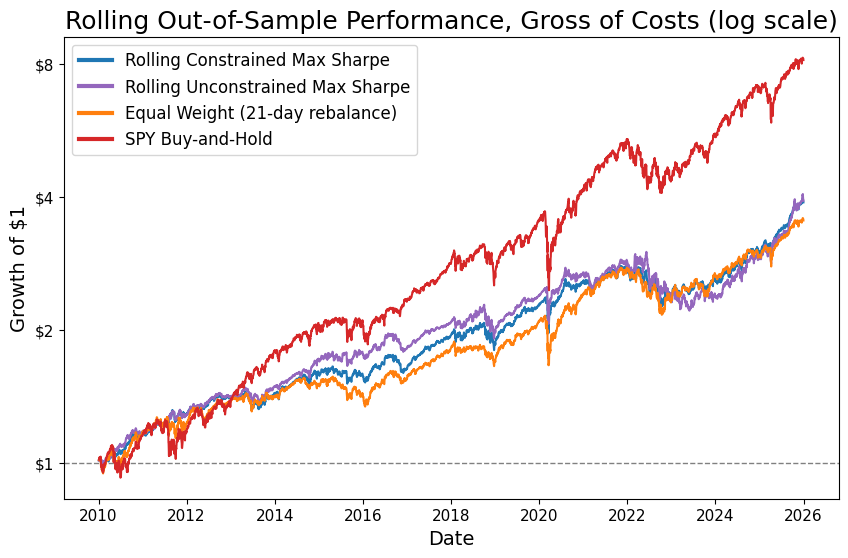

In [42]:
fig, ax = plt.subplots(figsize=(10, 6))

for name, port_returns in rolling_performance.items():
    ax.plot(
        (1 + port_returns).cumprod(),
        label=name,
        color=portfolio_styles[name]["color"],
        linewidth=1.5
    )

format_growth_axis(ax)

ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
ax.set_title("Rolling Out-of-Sample Performance, Gross of Costs (log scale)")

thicken_legend_lines(ax.legend())

fig.savefig(IMAGE_DIR / "out_of_sample_performance.png", dpi=150, bbox_inches="tight")
plt.show()

Before costs, SPY produces the highest cumulative growth: each dollar invested grows about 8.2-fold. The three diversified strategies end close together, at about 3.5 to 3.9 times their starting value.

The two maximum Sharpe strategies finish nearly level, but the unconstrained strategy takes a wider path. It stays above the constrained strategy continuously from February 2012 to December 2022, and below it from January 2023 to April 2025, during and after its deeper 2022–2023 drawdown. After several crossings, it finishes slightly ahead, moving back in front for good in November 2025.

This chart shows growth only. The risk differences between the strategies are clearer in the drawdown chart in Section 7.4.

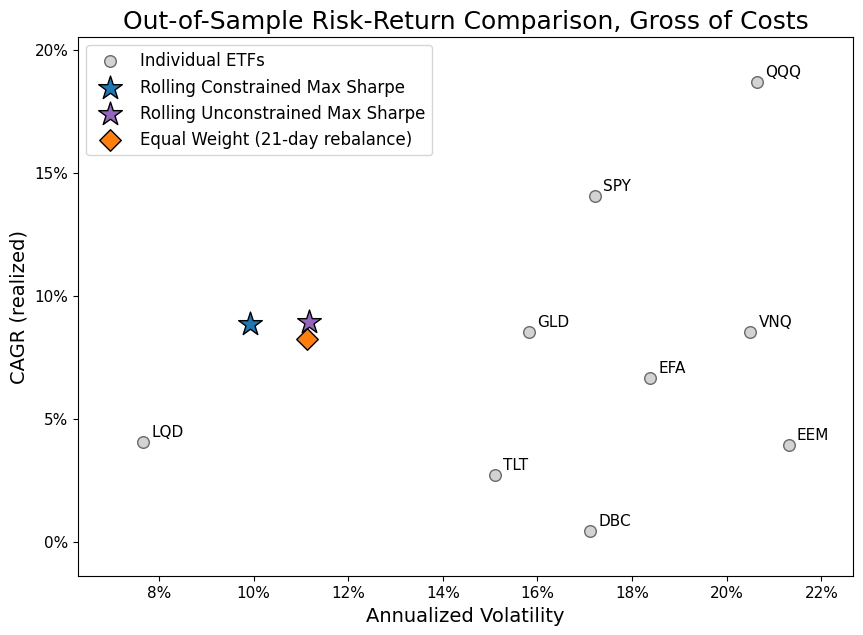

In [43]:
fig, ax = plt.subplots(figsize=(10, 7))

etf_points = pd.DataFrame({
    "Volatility": [annualized_volatility(backtest_returns.loc[evaluation_index, t]) for t in tickers],
    "CAGR": [cagr(backtest_returns.loc[evaluation_index, t]) for t in tickers]
}, index=tickers)

ax.scatter(
    etf_points["Volatility"],
    etf_points["CAGR"],
    s=70,
    color="lightgray",
    edgecolor="dimgray",
    label="Individual ETFs",
    zorder=2
)

for ticker, row in etf_points.iterrows():
    ax.annotate(ticker, (row["Volatility"], row["CAGR"]), xytext=(6, 4), textcoords="offset points", fontsize=11)

for name, port_returns in rolling_performance.items():
    if name == "SPY Buy-and-Hold":
        continue  # already shown as the SPY ETF point
    style = portfolio_styles[name]
    ax.scatter(
        annualized_volatility(port_returns),
        cagr(port_returns),
        s=style["s"],
        marker=style["marker"],
        color=style["color"],
        edgecolor="black",
        label=name,
        zorder=3
    )

ax.margins(0.1)
format_percent_axes(ax, x=True, y=True)

ax.set_xlabel("Annualized Volatility")
ax.set_ylabel("CAGR (realized)")
ax.set_title("Out-of-Sample Risk-Return Comparison, Gross of Costs")

ax.legend(loc="upper left")
plt.show()

The constrained strategy delivered a CAGR similar to the unconstrained strategy's and higher than equal weight's, at lower volatility than either. All three diversified strategies have much lower volatility than the major equity ETFs. This chart shows realized CAGR, while the efficient-frontier charts in Section 5 show arithmetic expected returns.

### 7.4 Out-of-Sample Drawdowns

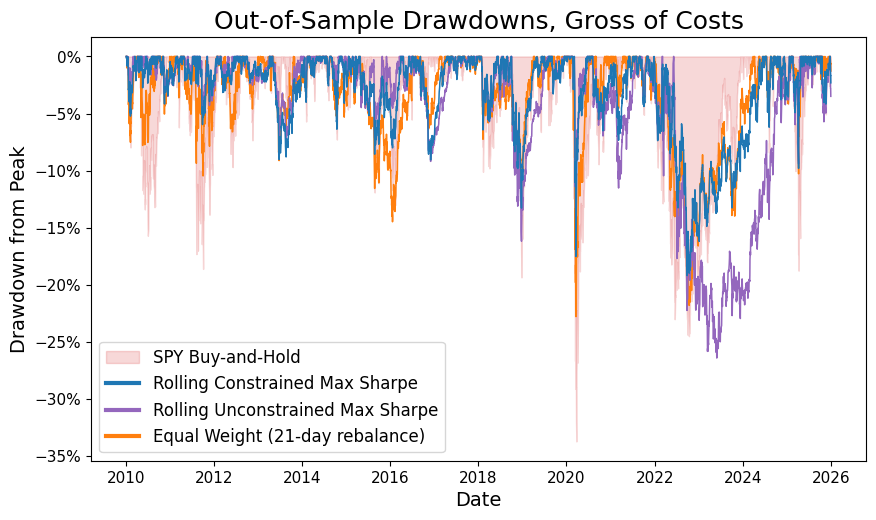

In [44]:
fig, ax = plt.subplots(figsize=(10, 5.5))

spy_drawdown = drawdown_series(spy_returns)

ax.fill_between(
    spy_drawdown.index,
    spy_drawdown,
    0,
    color=portfolio_styles["SPY Buy-and-Hold"]["color"],
    alpha=0.18,
    label="SPY Buy-and-Hold"
)

for name, port_returns in rolling_performance.items():
    if name == "SPY Buy-and-Hold":
        continue
    ax.plot(
        drawdown_series(port_returns),
        label=name,
        color=portfolio_styles[name]["color"],
        linewidth=1.1,
        zorder={"Rolling Constrained Max Sharpe": 4, "Rolling Unconstrained Max Sharpe": 3}.get(name, 2)
    )

format_percent_axes(ax, y=True)

ax.set_xlabel("Date")
ax.set_ylabel("Drawdown from Peak")
ax.set_title("Out-of-Sample Drawdowns, Gross of Costs")

thicken_legend_lines(ax.legend(loc="lower left"))
plt.show()

In [45]:
def worst_drawdown(port_returns):
    drawdown = drawdown_series(port_returns)
    trough = drawdown.idxmin()
    cumulative = (1 + port_returns.loc[:trough]).cumprod()
    peak = cumulative.idxmax() if cumulative.max() > 1 else port_returns.index[0]  # the initial $1 counts as a peak
    return {"Maximum Drawdown (%)": drawdown.min() * 100, "Peak": peak.date(), "Trough": trough.date()}


def average_holdings(rebalance_log, threshold=0.01):
    """Average number of ETFs above the threshold weight at a rebalance."""
    return (rebalance_log[tickers] > threshold).sum(axis=1).mean()


worst_drawdowns = pd.DataFrame.from_dict(
    {name: worst_drawdown(port_returns) for name, port_returns in rolling_performance.items()},
    orient="index"
)

worst_drawdowns["Avg ETFs Above 1% at Rebalances"] = pd.Series(
    {name: average_holdings(log) for name, log in rebalance_logs.items()}
)
worst_drawdowns.loc["SPY Buy-and-Hold", "Avg ETFs Above 1% at Rebalances"] = 1

worst_drawdowns.round(2)

,Maximum Drawdown (%),Peak,Trough,Avg ETFs Above 1% at Rebalances
Rolling Constrained Max Sharpe,-19.19,2021-12-27,2022-09-27,9.00
Rolling Unconstrained Max Sharpe,-26.41,2022-06-08,2023-05-31,3.24
Equal Weight (21-day rebalance),-22.78,2020-02-19,2020-03-20,9.00
SPY Buy-and-Hold,-33.72,2020-02-19,2020-03-23,1.00


The strategies' worst drawdowns come from different episodes:

- **SPY and equal weight:** worst points in the March 2020 sell-off.
- **Constrained strategy:** −19.2%, from December 2021 to September 2022, a period when stocks and long-term bonds fell together.
- **Unconstrained strategy:** −26.4%, from June 2022 to May 2023.

The unconstrained strategy's positions were also far more concentrated: on average, only about three ETFs held more than 1% at a rebalance. That concentration is a plausible contributor to its deeper drawdown, but return contributions by ETF are not broken down here, so this is not an established cause.

### 7.5 Rolling Portfolio Weights

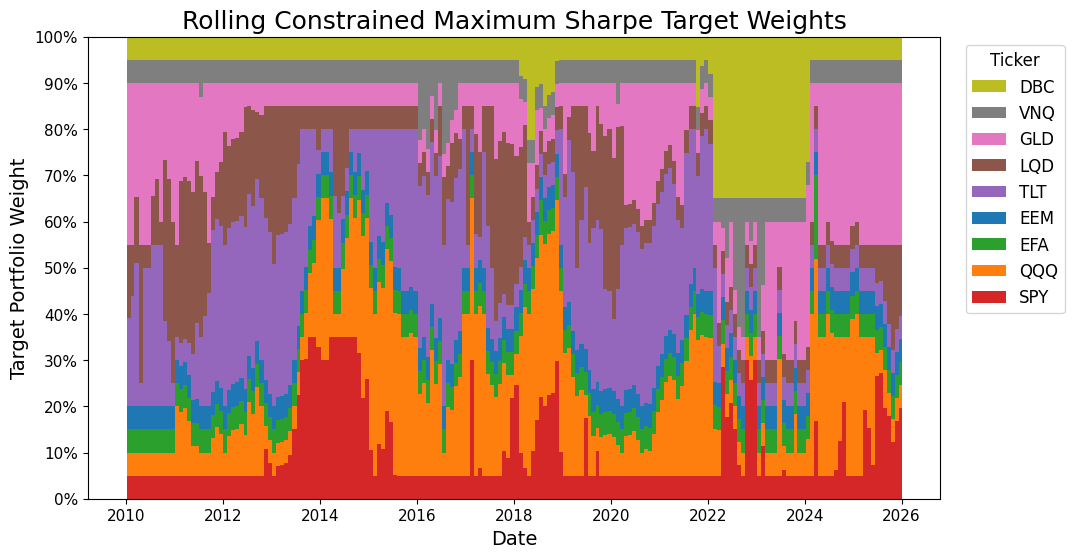

In [46]:
# Target weights at each rebalance (holdings drift between rebalances)
target_weights = constrained_rolling_log[tickers].copy()
target_weights.loc[evaluation_index[-1]] = target_weights.iloc[-1]  # extend the last step to the end of the sample

fig, ax = plt.subplots(figsize=(11, 6))

ax.stackplot(
    target_weights.index,
    target_weights.T.values,
    labels=tickers,
    colors=[ticker_colors[t] for t in tickers],
    step="post"
)

ax.set_ylim(0, 1)
format_percent_axes(ax, y=True)

ax.set_xlabel("Date")
ax.set_ylabel("Target Portfolio Weight")
ax.set_title("Rolling Constrained Maximum Sharpe Target Weights")

handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles[::-1],
    labels[::-1],
    title="Ticker",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.show()

In [47]:
def drifted_daily_weights(rebalance_log, asset_returns=backtest_returns):
    """End-of-day weights: each rebalance's holdings compound with asset returns until the next rebalance."""
    starts = [asset_returns.index.get_loc(date) for date in rebalance_log.index] + [len(asset_returns)]
    blocks = []
    for k, (start, end) in enumerate(zip(starts[:-1], starts[1:])):
        values = (1 + asset_returns.iloc[start:end]).cumprod() * rebalance_log[tickers].iloc[k].values
        blocks.append(values.div(values.sum(axis=1), axis=0))
    return pd.concat(blocks)


def longest_run(flags):
    """Length, first label, and last label of the longest run of True values."""
    best, length, run_start = (0, None, None), 0, None
    for label, flag in flags.items():
        if flag:
            run_start = label if length == 0 else run_start
            length += 1
            if length > best[0]:
                best = (length, run_start, label)
        else:
            length = 0
    return best


constrained_targets = constrained_rolling_log[tickers]
at_cap = pd.DataFrame(np.isclose(constrained_targets, 0.35), index=constrained_targets.index, columns=tickers)

share_at_floor = np.isclose(constrained_targets, 0.05).mean()
share_with_cap = at_cap.any(axis=1).mean()
dbc_cap_run = longest_run(at_cap["DBC"])

constrained_daily_weights = drifted_daily_weights(constrained_rolling_log)
drifted_weight_range = (constrained_daily_weights.min().min(), constrained_daily_weights.max().max())

print(f"Target weights at the 5% floor: {share_at_floor:.0%}")
print(f"Rebalances with at least one ETF at the 35% cap: {share_with_cap:.0%}")
print(f"Longest DBC run at the cap: {dbc_cap_run[0]} consecutive rebalances, {dbc_cap_run[1].date()} to {dbc_cap_run[2].date()}")
print(f"Actual (drifted) daily weights: {drifted_weight_range[0]:.1%} to {drifted_weight_range[1]:.1%}")

Target weights at the 5% floor: 66%
Rebalances with at least one ETF at the 35% cap: 85%
Longest DBC run at the cap: 23 consecutive rebalances, 2022-02-07 to 2023-12-08
Actual (drifted) daily weights: 3.8% to 40.7%


Target weights change substantially over time, and the bounds bind often:

- About 66% of all target weights sit at the 5% minimum.
- 85% of rebalances have at least one ETF at the 35% cap.
- For example, DBC is at the cap for 23 consecutive rebalances, from February 2022 to December 2023.

The chart shows target weights. Actual weights drift between rebalances and are not held to the 5–35% limits: across all trading days, they ranged from 3.8% to 40.7%.

The constraints limit concentration but do not eliminate sensitivity to changing return and covariance estimates. The bootstrap analysis in the next section tests this estimation sensitivity more directly.

## 8. Bootstrap Stability Analysis

Bootstrap resampling is used to test how sensitive the optimized portfolio weights are to changes in the historical return sample. Maximum Sharpe portfolios are re-estimated with and without the 5–35% bounds. Each resample draws daily returns independently, with replacement, from the full 2010–2025 sample. Unlike the rolling backtest, which estimates each allocation only from preceding observations, this is a sensitivity analysis on the whole historical dataset, not an out-of-sample test. Solutions that fail the solver and feasibility checks are excluded and counted.

In [48]:
n_bootstrap = 300

unconstrained_bootstrap_weights = []
constrained_bootstrap_weights = []
bootstrap_failures = {"Unconstrained": 0, "Constrained": 0}

rng = np.random.default_rng(42)

for _ in range(n_bootstrap):

    sample_indices = rng.integers(
        0,
        len(returns),
        size=len(returns)
    )

    sample_returns = returns.iloc[sample_indices]
    sample_cov = sample_returns.cov()

    # Unconstrained maximum Sharpe portfolio
    weights, ok, _ = optimize_weights(negative_sharpe, (sample_returns, sample_cov), bounds)

    if ok:
        unconstrained_bootstrap_weights.append(weights)
    else:
        bootstrap_failures["Unconstrained"] += 1

    # Constrained maximum Sharpe portfolio
    weights, ok, _ = optimize_weights(negative_sharpe, (sample_returns, sample_cov), bounds_constrained)

    if ok:
        constrained_bootstrap_weights.append(weights)
    else:
        bootstrap_failures["Constrained"] += 1

for name, failures in bootstrap_failures.items():
    print(f"{name}: {n_bootstrap - failures}/{n_bootstrap} resamples solved ({failures} failures)")

Unconstrained: 300/300 resamples solved (0 failures)
Constrained: 300/300 resamples solved (0 failures)


In [49]:
unconstrained_bootstrap_df = pd.DataFrame(
    unconstrained_bootstrap_weights,
    columns=tickers
)

constrained_bootstrap_df = pd.DataFrame(
    constrained_bootstrap_weights,
    columns=tickers
)

### 8.1 Bootstrap Weight Distributions

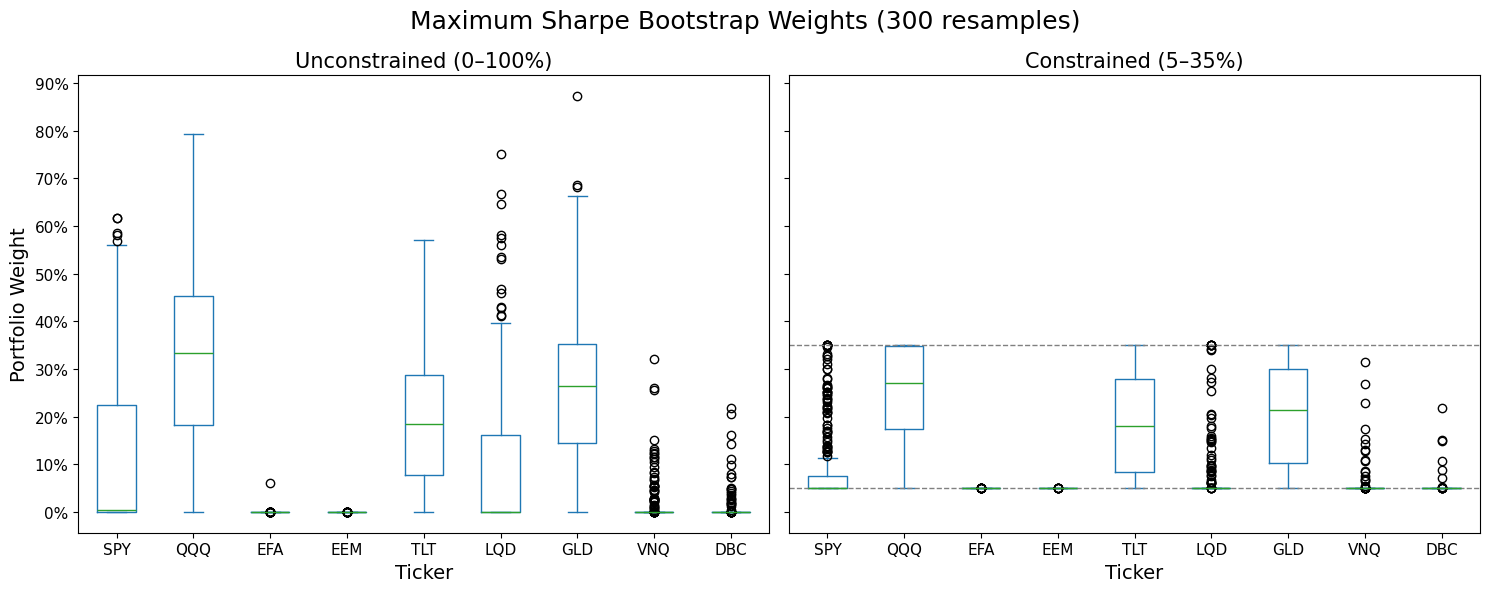

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

panels = [
    ("Unconstrained (0–100%)", unconstrained_bootstrap_df),
    ("Constrained (5–35%)", constrained_bootstrap_df)
]

for ax, (title, bootstrap_df) in zip(axes, panels):
    bootstrap_df.plot(kind="box", ax=ax)
    ax.set_title(title, fontsize=15)
    ax.set_xlabel("Ticker")

for bound in (0.05, 0.35):
    axes[1].axhline(bound, color="gray", linestyle="--", linewidth=1)

format_percent_axes(axes[0], y=True)
axes[0].set_ylabel("Portfolio Weight")

fig.suptitle(f"Maximum Sharpe Bootstrap Weights ({n_bootstrap} resamples)", fontsize=18)
fig.tight_layout()
plt.show()

Without bounds, QQQ, GLD, and TLT receive the largest typical allocations, and five ETFs (EFA, EEM, LQD, VNQ, and DBC) have median weights of zero. The wide weight distributions, especially for QQQ, SPY, and GLD, show that resampling the same history can produce large shifts in the optimized portfolio.

With the 5–35% bounds, QQQ, GLD, and TLT still receive the largest typical allocations, and the other six ETFs have median weights at the 5% floor. The bounds, shown as dashed lines, mechanically cap how far any weight can move.

### 8.2 Bootstrap Weight Stability

In [51]:
bootstrap_stability = pd.DataFrame({
    "Unconstrained Mean Weight (%)":
        unconstrained_bootstrap_df.mean(),

    "Unconstrained Weight Std (pp)":
        unconstrained_bootstrap_df.std(),

    "Constrained Mean Weight (%)":
        constrained_bootstrap_df.mean(),

    "Constrained Weight Std (pp)":
        constrained_bootstrap_df.std()
}) * 100

bootstrap_stability.round(1)

,Unconstrained Mean Weight (%),Unconstrained Weight Std (pp),Constrained Mean Weight (%),Constrained Weight Std (pp)
SPY,12.7,17.6,8.8,7.8
QQQ,32.1,18.2,24.7,9.6
EFA,0.0,0.4,5.0,0.0
EEM,0.0,0.0,5.0,0.0
TLT,19.1,13.9,18.4,10.3
LQD,8.6,14.7,6.8,5.8
GLD,25.9,14.9,20.7,10.8
VNQ,1.1,3.7,5.5,2.6
DBC,0.5,2.5,5.2,1.3


The constrained portfolio has a lower bootstrap weight standard deviation for every ETF that varies at all. The largest reductions are for SPY (17.6 → 7.8 pp) and LQD (14.7 → 5.8 pp).

Part of this reduction is mechanical. A weight confined to 5–35% cannot have a standard deviation above 15 pp, and an ETF pinned at the 5% floor has no variation by construction. Lower dispersion therefore shows that the bounds contain the effect of estimation error on the final allocation. It does not show that the constrained optimizer estimates expected returns more accurately.

## 9. Conclusion

This project applied mean-variance portfolio optimization across a diversified ETF universe and tested how allocation constraints affect performance and stability.

In-sample optimization produced a concentrated maximum Sharpe portfolio. Adding 5% to 35% allocation bounds reduced concentration at the cost of some estimated in-sample efficiency (Sharpe ratio 1.14 → 1.01).

In the rolling out-of-sample backtest, holdings drifted between rebalances every 21 trading days, and trades were assumed to execute at the closing price used for estimation. Before costs:

- The constrained maximum Sharpe strategy had a Sharpe ratio of 0.91, compared with 0.82 for the unconstrained strategy, 0.77 for equal weight, and 0.85 for SPY buy-and-hold.
- It also had the shallowest maximum drawdown (−19.2%) and required less turnover than the unconstrained strategy.
- SPY produced by far the highest CAGR, with substantially higher volatility and a deeper drawdown.

Transaction costs narrow the constrained strategy's lead over equal weight and remove its lead over SPY, but widen its lead over the unconstrained strategy. At 25 bps per dollar traded, the constrained strategy's Sharpe ratio falls to 0.85, approximately equal to SPY at the reported two-decimal precision. The unconstrained strategy, which trades the most, falls to 0.74, below equal weight's 0.76.

Bootstrap resampling of the full sample showed that optimized weights are highly sensitive to estimation error. The bounds narrowed the spread of weights for every ETF that varied, partly by construction.

Taken together, the results are consistent with the view that unconstrained optimization overfits historical estimates. Simple allocation bounds traded some in-sample efficiency for allocations that held up better out of sample, and their advantage over the unconstrained strategy grew once trading costs were included. However, these are historical point estimates from a single 16-year path, and no significance tests were performed. They support this view, but statistical superiority of any strategy has not been established.

**Limitations:**

- The analysis assumes a zero risk-free rate.
- Transaction costs are modeled only as a flat proportional charge per dollar traded. Market impact, time-varying spreads, and taxes are excluded.
- Trades are assumed to execute instantly at the closing price used for estimation.
- The rolling strategies rely on historical return and covariance estimates.
- The bootstrap resamples daily returns independently and therefore does not preserve serial dependence.

Possible extensions include execution-lag and richer cost models, a nonzero risk-free rate, covariance shrinkage, alternative expected-return models, and block bootstrap methods.